In [1]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten
import matplotlib.pyplot as plt

2026-02-24 00:03:45.627897: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 00:03:45.752233: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 00:03:49.519362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 00:04:00.199754: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:

(trainX,trainY),(testX,testY)=load_data()
print(trainX.shape,trainY.shape)
print(testX.shape,testY.shape)
inputs = Input(shape=(28, 28))
x=Flatten()(inputs)
x1=Dense(512,activation='relu')(x)
x2=Dense(1024,activation='relu')(x1)
x3=Dense(512,activation='relu')(x2)
outputs=Dense(10,activation='softmax')(x3)
model=Model(inputs,outputs)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# history=model.fit(trainX,trainY,epochs=10,batch_size=32,validation_data=(testX,testY),verbose=1)
history=model.fit(trainX,trainY,epochs=1,batch_size=32,validation_split=0.1,verbose=1)

loss,accuracy=model.evaluate(testX,testY,verbose=0)
print(f"loss={loss}")
print(f"accuracy={accuracy}")

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


2026-02-24 00:04:11.416555: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9072 - loss: 0.9040 - val_accuracy: 0.9430 - val_loss: 0.2041
loss=0.23593610525131226
accuracy=0.9355999827384949


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 28, 28)
(10000, 10)


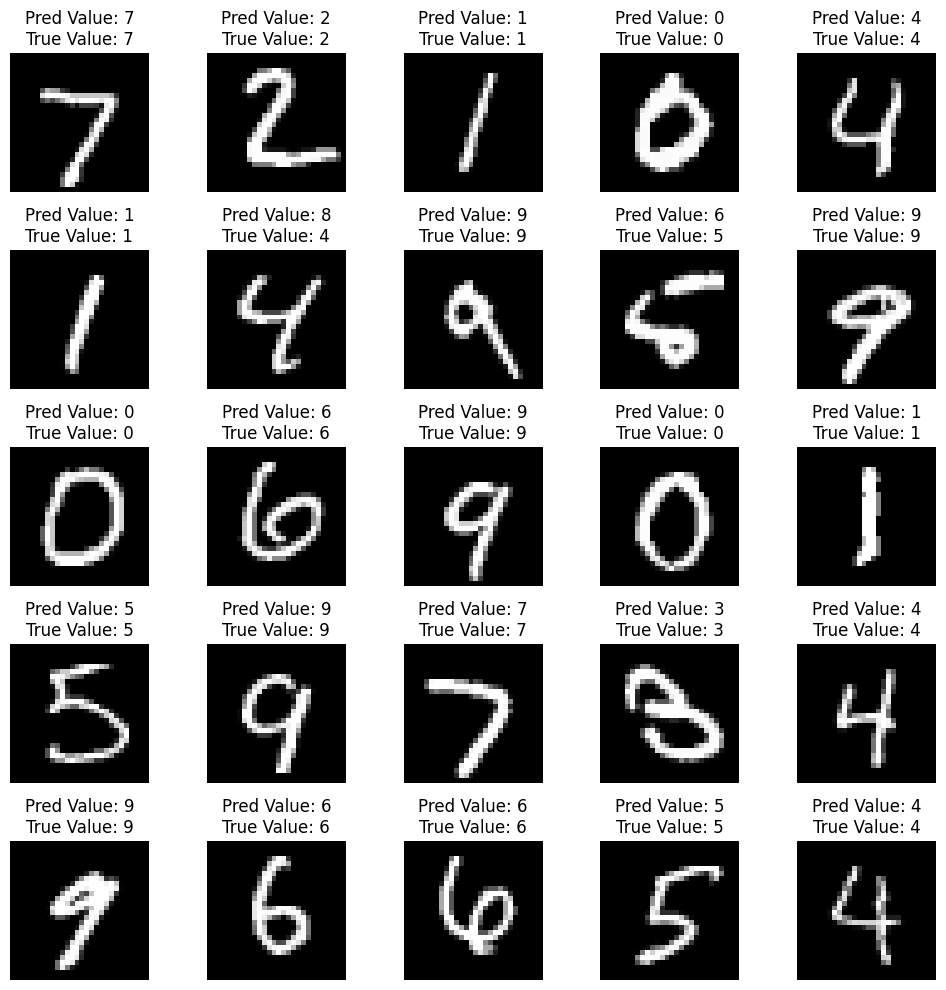

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
predY = model.predict(testX)
print(testX.shape)
print(predY.shape)
pred_labels = predY.argmax(axis=1)

# Plot 25 test images with predictions
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(testX[i], cmap='gray')
    plt.title(f"Pred Value: {pred_labels[i]}\nTrue Value: {testY[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
